## A PROJECT ON DATA ANALYSIS AND VISUALIZATION OF FOOTBALL MATCHES

# Importing Required Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

#  Loading the Dataset on 'goalscorers'

# Component 1 & 2

In [2]:
df = pd.read_csv("goalscorers.csv")
df.head()

,date,home_team,away_team,team,scorer,minute,own_goal,penalty
0,1916-07-02,Chile,Uruguay,Uruguay,José Piendibene,44.0,False,False
1,1916-07-02,Chile,Uruguay,Uruguay,Isabelino Gradín,55.0,False,False
2,1916-07-02,Chile,Uruguay,Uruguay,Isabelino Gradín,70.0,False,False
3,1916-07-02,Chile,Uruguay,Uruguay,José Piendibene,75.0,False,False
4,1916-07-06,Argentina,Chile,Argentina,Alberto Ohaco,2.0,False,False


# Understanding the Data

# The dataset contains information about football matches including teams, players, and goal details. It includes features like date, team names, scorer, minute of goal, and penalty information. The dataset consists of multiple rows and columns with both categorical and numerical data.

In [3]:
df.columns

Index(['date', 'home_team', 'away_team', 'team', 'scorer', 'minute',
       'own_goal', 'penalty'],
      dtype='object')

In [4]:
df.shape

(44362, 8)

In [5]:
df.dtypes

date          object
home_team     object
away_team     object
team          object
scorer        object
minute       float64
own_goal        bool
penalty         bool
dtype: object

# Data Cleaning on 'Date' column

In [6]:
df['date'] = pd.to_datetime(df['date'])

In [7]:
df.dtypes

date         datetime64[ns]
home_team            object
away_team            object
team                 object
scorer               object
minute              float64
own_goal               bool
penalty                bool
dtype: object

# Feature Engineering ( Creating Year column )

In [8]:
df['year']= df['date'].dt.year

In [9]:
df.head()

,date,home_team,away_team,team,scorer,minute,own_goal,penalty,year
0,1916-07-02,Chile,Uruguay,Uruguay,José Piendibene,44.0,False,False,1916
1,1916-07-02,Chile,Uruguay,Uruguay,Isabelino Gradín,55.0,False,False,1916
2,1916-07-02,Chile,Uruguay,Uruguay,Isabelino Gradín,70.0,False,False,1916
3,1916-07-02,Chile,Uruguay,Uruguay,José Piendibene,75.0,False,False,1916
4,1916-07-06,Argentina,Chile,Argentina,Alberto Ohaco,2.0,False,False,1916


#  Checking Missing Values

In [10]:
df.isnull().sum()

date           0
home_team      0
away_team      0
team           0
scorer        49
minute       259
own_goal       0
penalty        0
year           0
dtype: int64

# Handling the Null Values by dropping

In [11]:
df =df.dropna()

In [12]:
df.isnull().sum()

date         0
home_team    0
away_team    0
team         0
scorer       0
minute       0
own_goal     0
penalty      0
year         0
dtype: int64

# Checking the duplicates

In [13]:
df.duplicated()

0        False
1        False
2        False
3        False
4        False
         ...  
44357    False
44358    False
44359    False
44360    False
44361    False
Length: 44102, dtype: bool

# Understaning other properties of dataframe

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 44102 entries, 0 to 44361
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   date       44102 non-null  datetime64[ns]
 1   home_team  44102 non-null  object        
 2   away_team  44102 non-null  object        
 3   team       44102 non-null  object        
 4   scorer     44102 non-null  object        
 5   minute     44102 non-null  float64       
 6   own_goal   44102 non-null  bool          
 7   penalty    44102 non-null  bool          
 8   year       44102 non-null  int32         
dtypes: bool(2), datetime64[ns](1), float64(1), int32(1), object(4)
memory usage: 2.6+ MB


# The "describe" property gives an over view on "numerical columns" only

In [15]:
df.describe()

,date,minute,year
count,44102,44102.000000,44102.000000
mean,1997-07-11 02:13:24.861457536,50.012652,1996.982223
min,1916-07-02 00:00:00,1.000000,1916.000000
25%,1986-06-29 00:00:00,28.000000,1986.000000
50%,2002-06-15 00:00:00,51.000000,2002.000000
75%,2013-10-11 00:00:00,73.000000,2013.000000
max,2024-07-14 00:00:00,122.000000,2024.000000
std,NaN,26.358310,21.723660


# The below property is to describe numerical as well as categorical columns

In [16]:
df.describe(include = 'all')

,date,home_team,away_team,team,scorer,minute,own_goal,penalty,year
count,44102,44102,44102,44102,44102,44102.000000,44102,44102,44102.000000
unique,NaN,220,220,220,14248,NaN,2,2,NaN
top,NaN,Brazil,Uruguay,Brazil,Cristiano Ronaldo,NaN,False,False,NaN
freq,NaN,1023,787,1051,108,NaN,43281,41142,NaN
mean,1997-07-11 02:13:24.861457536,NaN,NaN,NaN,NaN,50.012652,NaN,NaN,1996.982223
min,1916-07-02 00:00:00,NaN,NaN,NaN,NaN,1.000000,NaN,NaN,1916.000000
25%,1986-06-29 00:00:00,NaN,NaN,NaN,NaN,28.000000,NaN,NaN,1986.000000
50%,2002-06-15 00:00:00,NaN,NaN,NaN,NaN,51.000000,NaN,NaN,2002.000000
75%,2013-10-11 00:00:00,NaN,NaN,NaN,NaN,73.000000,NaN,NaN,2013.000000
max,2024-07-14 00:00:00,NaN,NaN,NaN,NaN,122.000000,NaN,NaN,2024.000000


# Exploratory Data Analysis

This project performs Exploratory Data Analysis (EDA) on a football dataset(goalscorers) to evaluate patterns
in goal scoring, team performance, and match trends.

#  UNIVARIATE ANALYSIS - Analyzing a single column at a time .

# 1. Goal Timing - Histogram ( to check the frequency distribution)

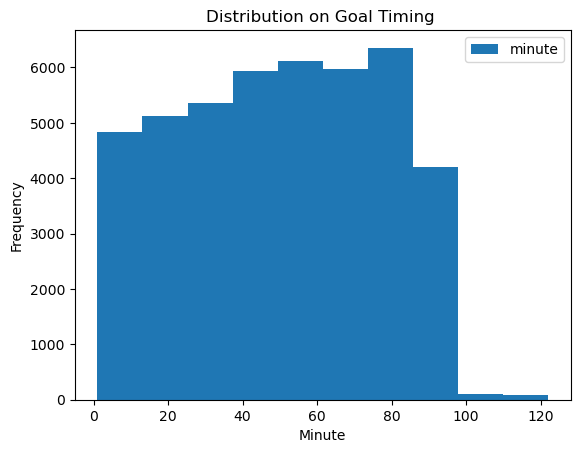

In [17]:
df.plot(y='minute', kind='hist')
plt.title("Distribution on Goal Timing ")
plt.xlabel("Minute")
plt.ylabel("Frequency")
plt.show()

# Goal Timing - Box Plot ( to detect the outliers )

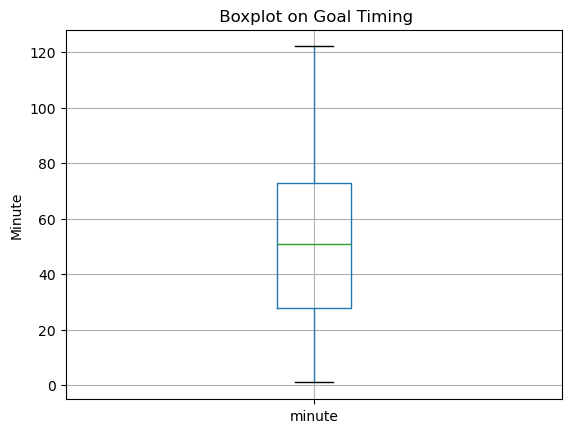

In [18]:
df.boxplot(column='minute')
plt.title(" Boxplot on Goal Timing")
plt.ylabel("Minute")
plt.show()

 # BIVARIATE ANALYSIS - Analyzing two columns at a time .

# 1. Year vs Goal Minute - Scatter chart ( relates two numerical columns )

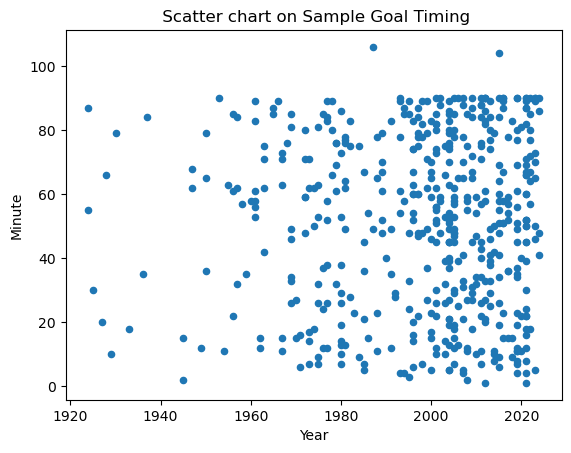

In [19]:
df_sample = df.sample(500)

df_sample.plot(x='year', y='minute', kind='scatter')
plt.title(" Scatter chart on Sample Goal Timing")
plt.xlabel("Year")
plt.ylabel("Minute")
plt.show()

# 2. Year vs Goal Minute - Line chart ( for trends & patterns )

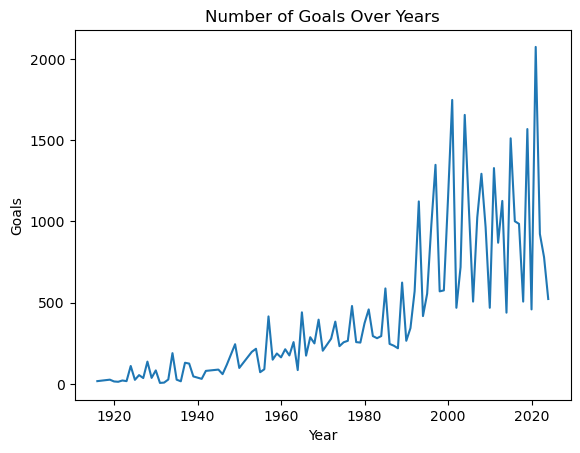

In [20]:
df['year'].value_counts().sort_index().plot()
plt.title("Number of Goals Over Years")
plt.xlabel("Year")
plt.ylabel("Goals")
plt.show()

# 3. Top Teams vs Goals - Bar Chart ( comparison)

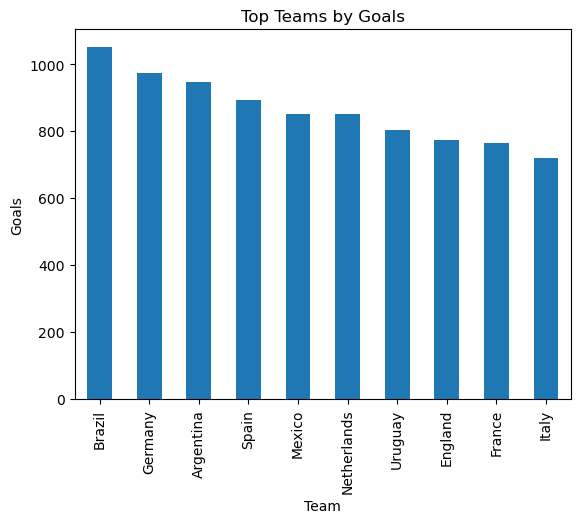

In [21]:
df['team'].value_counts().head(10).plot(kind='bar')
plt.title("Top Teams by Goals")
plt.xlabel("Team")
plt.ylabel("Goals")
plt.show()

##  KEY INSIGHTS :

- Brazil holds the highest goalcount followed by Germany , Argentina and so on showing the strong team performance.
- Most of the goals are scored during the middle phase of the match having fewer goals in the beginning and ending of the match .
- There is an increase in total goals over years especially after 2000.

# Component 3 

 # What is Career Analysis of a player ??

## Analyzing one player's performance over time , goals , matches ,progress , Trend ,etc.

In [22]:
df.columns

Index(['date', 'home_team', 'away_team', 'team', 'scorer', 'minute',
       'own_goal', 'penalty', 'year'],
      dtype='object')

In [23]:
df['scorer'].head()

0     José Piendibene
1    Isabelino Gradín
2    Isabelino Gradín
3     José Piendibene
4       Alberto Ohaco
Name: scorer, dtype: object

In [24]:
df['scorer'].value_counts().head(10)

scorer
Cristiano Ronaldo      108
Robert Lewandowski      63
Romelu Lukaku           60
Harry Kane              58
Lionel Messi            55
Edin Džeko              50
Ali Daei                49
Miroslav Klose          48
Carlos Ruiz             47
Aleksandar Mitrović     47
Name: count, dtype: int64

# Lets perform career analysis on Cristiano Ronaldo , the one with the highest scorings. The dataframe of the player is stored in "Player_data".

In [25]:
player_data = df[df['scorer'] == 'Cristiano Ronaldo']
player_data.head()

,date,home_team,away_team,team,scorer,minute,own_goal,penalty,year
23831,2004-06-12,Portugal,Greece,Portugal,Cristiano Ronaldo,90.0,False,False,2004
24021,2004-06-30,Portugal,Netherlands,Portugal,Cristiano Ronaldo,26.0,False,False,2004
24303,2004-09-04,Latvia,Portugal,Portugal,Cristiano Ronaldo,57.0,False,False,2004
24478,2004-09-08,Portugal,Estonia,Portugal,Cristiano Ronaldo,75.0,False,False,2004
24755,2004-10-13,Portugal,Russia,Portugal,Cristiano Ronaldo,39.0,False,False,2004


In [26]:
player_data.shape

(108, 9)

In [27]:
player_data.describe()

,date,minute,year
count,108,108.000000,108.000000
mean,2015-11-27 19:06:40,52.870370,2015.287037
min,2004-06-12 00:00:00,2.000000,2004.000000
25%,2012-04-24 06:00:00,29.750000,2011.750000
50%,2017-01-18 00:00:00,59.000000,2016.500000
75%,2019-11-14 18:00:00,76.250000,2019.000000
max,2023-11-16 00:00:00,90.000000,2023.000000
std,NaN,27.392643,5.716104


# Lets have advanced graphs using seaborn 

In [28]:
import seaborn as sns

#  Univariate Analysis 

# 1. Goal Minutes Distribution - Histogram

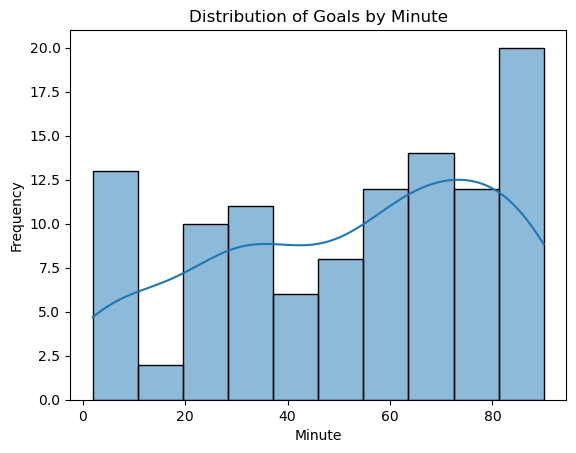

In [29]:
sns.histplot(player_data['minute'], bins=10, kde=True)
plt.title("Distribution of Goals by Minute")
plt.xlabel("Minute")
plt.ylabel("Frequency")
plt.show()

# Conclusion - Most goals are scored in the middle and final minutes of the match by Ronaldo.

# BIVARIATE ANALYSIS 

# 1. Years vs Goals - Bar Chart

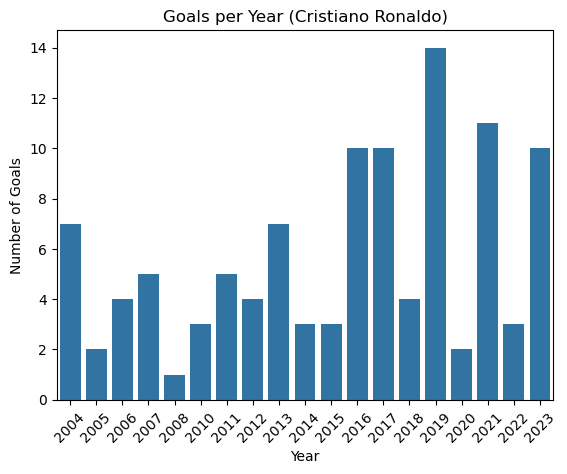

In [30]:
yearly_goals = player_data['year'].value_counts().sort_index()

sns.barplot(x=yearly_goals.index, y=yearly_goals.values)
plt.title("Goals per Year (Cristiano Ronaldo)")
plt.xlabel("Year")
plt.ylabel("Number of Goals")
plt.xticks(rotation=45)
plt.show()

# Conclusion - Ronaldo performed best in the years with the highest bars, showing peak goal-scoring periods.

# 2. Home vs Away Goals - Count Plot

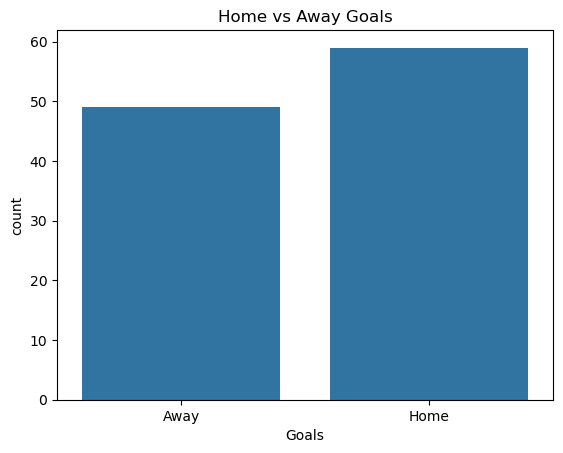

In [31]:
sns.countplot(x=(player_data['team'] == player_data['home_team']))

plt.xticks([0,1], ['Away', 'Home'])
plt.title('Home vs Away Goals')
plt.xlabel('Goals')
plt.show()

# Conclusion - Ronaldo has scored slightly more goals in home matches

# 3. Top Teams he scored against vs opponent - Donut Chart

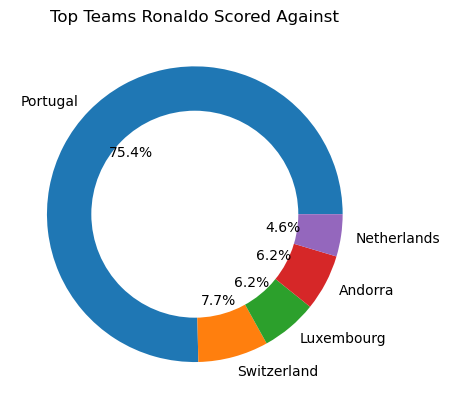

In [32]:
top_opponents = player_data['away_team'].value_counts().head(5)
plt.pie(top_opponents, labels=top_opponents.index, autopct='%1.1f%%')
centre_circle = plt.Circle((0,0), 0.70, fc='white')
plt.gca().add_artist(centre_circle)
plt.title('Top Teams Ronaldo Scored Against')
plt.show()

# Conclusion - Ronaldo has scored frequently  against certain teams, showing dominance.

# 4. Penalty vs Non Penalty Goals  - Pie Chart

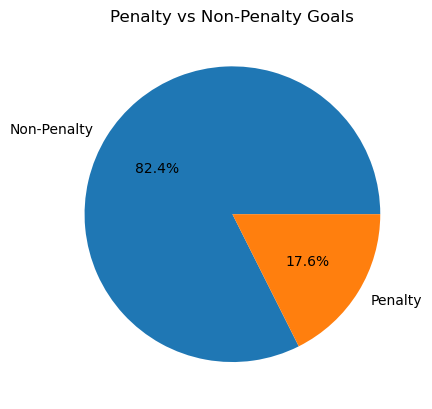

In [33]:
g = player_data['penalty'].value_counts()

plt.pie(g, labels=['Non-Penalty', 'Penalty'], autopct='%1.1f%%')

plt.title('Penalty vs Non-Penalty Goals')
plt.show()

# Conclusion - Most goals are non-penalty goals, highlighting strong open-play performance.

# 5. Year vs Goal Minute (with Penalty Highlight) -  Scatter  Chart

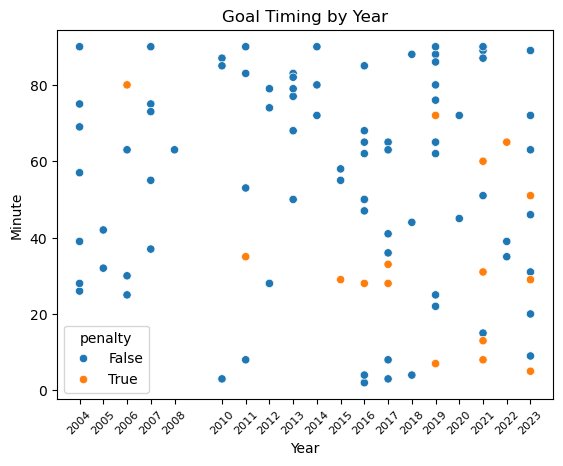

In [34]:
sns.scatterplot(x='year', y='minute', hue='penalty', data=player_data)

plt.xticks(sorted(player_data['year'].unique()), rotation=45, fontsize=8)

plt.title("Goal Timing by Year")
plt.xlabel("Year")
plt.ylabel("Minute")
plt.show()

 # Conclusion - The scatter plot shows that Cristiano Ronaldo has scored goals across all match minutes over different years.

# Final Conclusion 

# Best Performance

- Cristiano Ronaldo shows consistent goal scoring with noticeable peak years.  
- Most goals are scored in the second half of matches.  
- Peak performance is observed in certain years.  
- Strong performance against multiple opponents with good non penalty goals. 

# Weak Performance 
- Some years have lower goal scoring.  
- Fewer goals in early minutes.  
- Slight inconsistency in performance.  